In [ ]:
# Install dependencies & imports -----------------------------
!pip install -q opencv-python-headless matplotlib numpy pyyaml

import cv2, os, glob, shutil, random, yaml
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from google.colab import drive

print("✅ Libraries ready")

✅ Libraries ready


In [ ]:
# Mount Drive + define all paths -----------------------------
drive.mount('/content/drive')

BASE        = '/content/drive/MyDrive/FYP'

# Input: existing dataset -----------------------------
RAW_DIR     = f'{BASE}/data/dataset'      # side-by-side pairs already here

# YOLO annotation outputs -----------------------------
YOLO_IMAGES = f'{BASE}/yolo_data/images'  # OCT-only images (for YOLO)
YOLO_LABELS = f'{BASE}/yolo_data/labels'  # YOLO bbox .txt files
YOLO_VISUAL = f'{BASE}/yolo_data/visual'  # bbox drawn on OCT for verification

# U-Net annotation outputs -----------------------------
UNET_IMAGES = f'{BASE}/unet_data/images'  # OCT-only images (for U-Net)
UNET_MASKS  = f'{BASE}/unet_data/masks'   # class-ID masks (pixel = 0-5)
UNET_VISUAL = f'{BASE}/unet_data/visual'  # overlay for verification

# Final split folders (created in Cell 8) -----------------------------
YOLO_SPLIT  = f'{BASE}/yolo_dataset'
UNET_SPLIT  = f'{BASE}/unet_dataset'

for p in [YOLO_IMAGES, YOLO_LABELS, YOLO_VISUAL,
          UNET_IMAGES, UNET_MASKS,  UNET_VISUAL]:
    os.makedirs(p, exist_ok=True)

# Collect all raw side-by-side images -----------------------------
all_raw = []
for ext in ['*.png','*.jpg','*.jpeg','*.bmp','*.tif']:
    all_raw.extend(glob.glob(f'{RAW_DIR}/**/{ext}', recursive=True))
    all_raw.extend(glob.glob(f'{RAW_DIR}/{ext}'))
all_raw = sorted(set(all_raw))

print(f"✅ Found {len(all_raw)} raw images in {RAW_DIR}")
if len(all_raw) == 0:
    print("⚠️  No images found — check the path above matches your Drive folder")
else:
    print(f"   First file: {os.path.basename(all_raw[0])}")
    sample = cv2.imread(all_raw[0])
    print(f"   Sample image size: {sample.shape[1]} × {sample.shape[0]} px (full side-by-side)")
    print(f"   OCT half size:     {sample.shape[1]//2} × {sample.shape[0]} px")


Mounted at /content/drive
✅ Found 3049 raw images in /content/drive/MyDrive/FYP/data/dataset
   First file: 100_100_1.png
   Sample image size: 1140 × 380 px (full side-by-side)
   OCT half size:     570 × 380 px


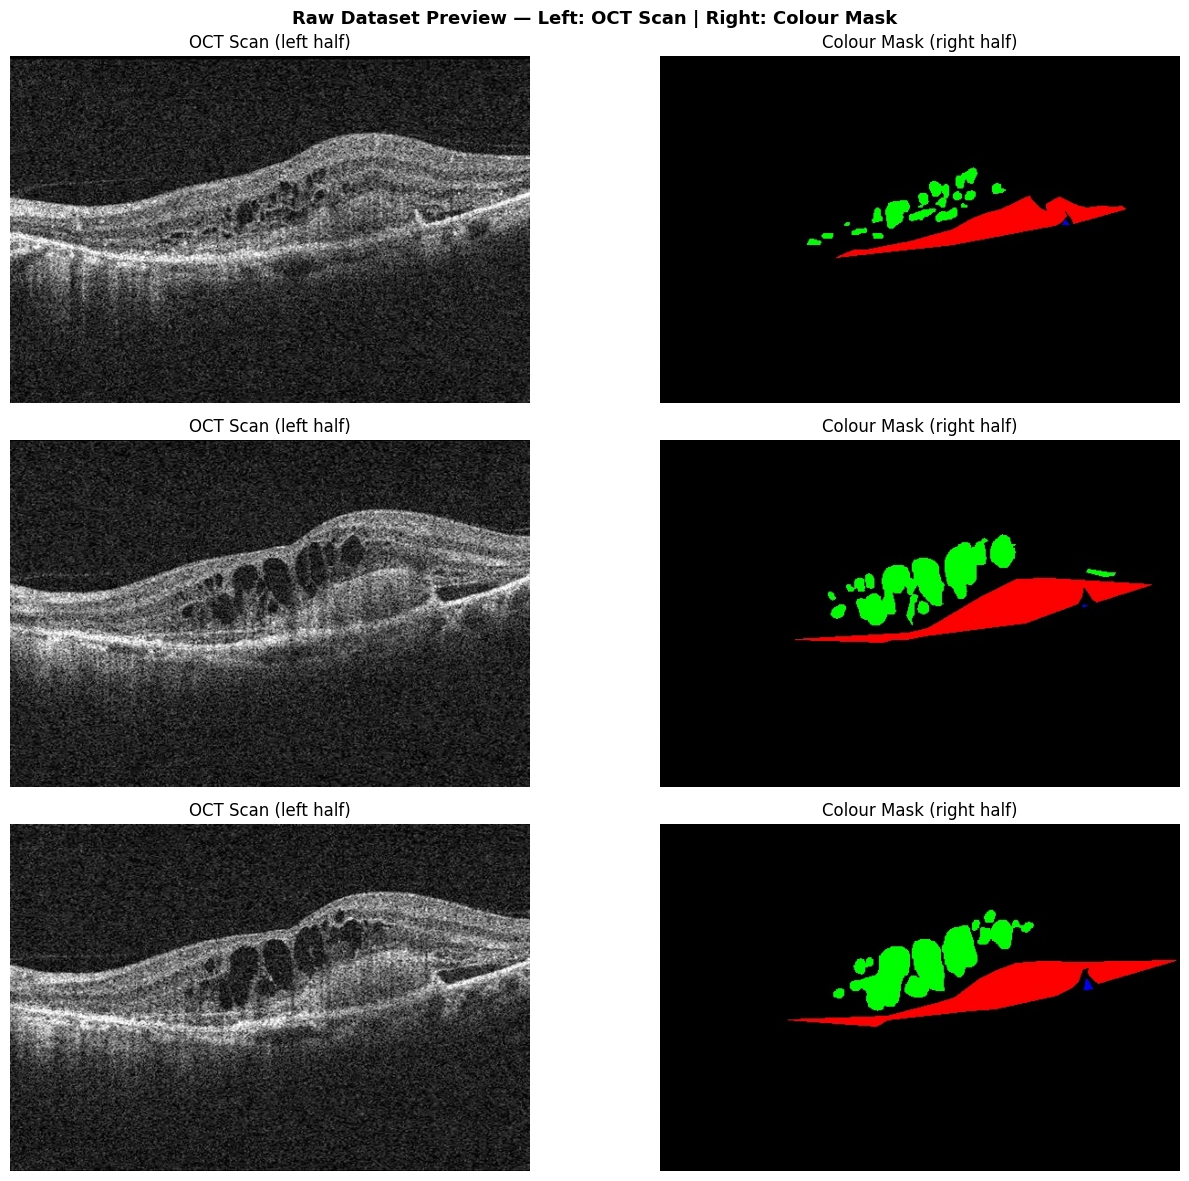

Saved → /content/raw_preview.png


In [ ]:
# Preview raw side-by-side pairs -----------------------------
n_preview = min(3, len(all_raw))

fig, axes = plt.subplots(n_preview, 2, figsize=(14, 4*n_preview))
if n_preview == 1: axes = axes[np.newaxis, :]
fig.suptitle('Raw Dataset Preview — Left: OCT Scan | Right: Colour Mask',
             fontsize=13, fontweight='bold')

for i, path in enumerate(all_raw[:n_preview]):
    img = cv2.imread(path)
    h, w = img.shape[:2]
    left  = cv2.cvtColor(img[:, :w//2],  cv2.COLOR_BGR2RGB)
    right = cv2.cvtColor(img[:, w//2:],  cv2.COLOR_BGR2RGB)

    axes[i,0].imshow(left);  axes[i,0].set_title('OCT Scan (left half)')
    axes[i,1].imshow(right); axes[i,1].set_title('Colour Mask (right half)')
    axes[i,0].set_ylabel(os.path.basename(path), fontsize=8)
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('/content/raw_preview.png', dpi=120)
plt.show()
print("Saved → /content/raw_preview.png")


In [ ]:
# Define class colour map -----------------------------
#
# Based on  dataset image:
#   Magenta (255,0,255) → IS/OS layer
#   Yellow  (255,255,0) → SHRM
#   Other classes may appear in other images of  dataset.
#
# COLOUR_TOLERANCE: how far a pixel's colour can be from the reference RGB
# and still be matched to that class. 40 works well for clean masks;
# raise to 60 if  annotation tool uses anti-aliased edges.

NUM_CLASSES        = 6
COLOUR_TOLERANCE   = 40

CLASS_INFO = {
    0: {'name': 'Background', 'rgb': (  0,   0,   0)},   # Black
    1: {'name': 'SRF',        'rgb': (255,   0,   0)},   # Red
    2: {'name': 'IRF',        'rgb': (  0, 255,   0)},   # Green
    3: {'name': 'PED',        'rgb': (  0,   0, 255)},   # Blue
    4: {'name': 'IS/OS',      'rgb': (255,   0, 255)},   # Magenta  
    5: {'name': 'SHRM',       'rgb': (255, 255,   0)},   # Yellow   
}

#  Colour conversion helpers -----------------------------
def rgb_mask_to_class(mask_bgr):
    """
    Convert a BGR colour mask → single-channel uint8 class-ID mask.
    Each pixel is assigned the class whose RGB reference is closest
    (Euclidean distance in RGB space).
    """
    mask_rgb  = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2RGB)
    h, w, _   = mask_rgb.shape
    pixels    = mask_rgb.reshape(-1, 3).astype(np.float32)
    best_dist = np.full(len(pixels), np.inf)
    best_cls  = np.zeros(len(pixels), dtype=np.uint8)   # default = background

    for cid, info in CLASS_INFO.items():
        ref  = np.array(info['rgb'], dtype=np.float32)
        dist = np.linalg.norm(pixels - ref, axis=1)
        better = dist < best_dist
        best_dist[better] = dist[better]
        best_cls[better]  = cid

    return best_cls.reshape(h, w)

def class_mask_to_rgb(class_mask):
    """Convert a class-ID mask (0-5) → RGB colour image for display."""
    h, w = class_mask.shape
    rgb  = np.zeros((h, w, 3), dtype=np.uint8)
    for cid, info in CLASS_INFO.items():
        rgb[class_mask == cid] = info['rgb']
    return rgb

#  Print colour map -----------------------------
print("── Class Colour Map ──────────────────────────────────────────────────")
print(f"  {'ID':<4} {'Name':<14} {'RGB'}")
print("  " + "-"*38)
for cid, info in CLASS_INFO.items():
    r,g,b = info['rgb']
    print(f"  {cid:<4} {info['name']:<14} RGB({r:3},{g:3},{b:3})")

print(f"\n  Colour tolerance : ±{COLOUR_TOLERANCE} (Euclidean distance in RGB)")
print("✅ Helpers ready: rgb_mask_to_class()  class_mask_to_rgb()")


── Class Colour Map ──────────────────────────────────────────────────
  ID   Name           RGB
  --------------------------------------
  0    Background     RGB(  0,  0,  0)
  1    SRF            RGB(255,  0,  0)
  2    IRF            RGB(  0,255,  0)
  3    PED            RGB(  0,  0,255)
  4    IS/OS          RGB(255,  0,255)
  5    SHRM           RGB(255,255,  0)

  Colour tolerance : ±40 (Euclidean distance in RGB)
✅ Helpers ready: rgb_mask_to_class()  class_mask_to_rgb()


In [ ]:
# Generate YOLO images + bounding-box labels -----------------------------


YOLO_SIZE = (640, 640)    # (width, height) for YOLO 

MORPH_K   = 5             # morphological kernel size (noise removal)
MIN_AREA  = 0.003         # minimum bbox area as fraction of image (filters noise)

saved_ok, no_roi, skipped = 0, 0, 0

for raw_path in sorted(all_raw):
    img = cv2.imread(raw_path)
    if img is None:
        skipped += 1; continue

    h_full, w_full = img.shape[:2]
    oct_bgr   = img[:, :w_full//2]     # left half  = OCT scan
    mask_bgr  = img[:, w_full//2:]     # right half = colour mask

    orig_h, orig_w = oct_bgr.shape[:2]

    # Resize OCT for YOLO if requested-----------------------------
    if YOLO_SIZE is not None:
        yolo_w, yolo_h = YOLO_SIZE
        yolo_oct  = cv2.resize(oct_bgr, (yolo_w, yolo_h),
                               interpolation=cv2.INTER_LINEAR)
        scale_x   = yolo_w / orig_w     # ratio to rescale bbox coords
        scale_y   = yolo_h / orig_h
    else:
        yolo_oct  = oct_bgr.copy()
        yolo_w, yolo_h = orig_w, orig_h
        scale_x = scale_y = 1.0

    # Convert colour mask to grayscale non-black mask for bbox -----------------------------
    # Use HSV to detect any coloured (non-black) pixel
    hsv      = cv2.cvtColor(mask_bgr, cv2.COLOR_BGR2HSV)
    col_mask = cv2.inRange(hsv,
                           np.array([0,  30, 30]),
                           np.array([179, 255, 255]))

    # Clean up noise
    kernel   = np.ones((MORPH_K, MORPH_K), np.uint8)
    col_mask = cv2.morphologyEx(col_mask, cv2.MORPH_OPEN,  kernel)
    col_mask = cv2.morphologyEx(col_mask, cv2.MORPH_CLOSE, kernel)

    coords = np.column_stack(np.where(col_mask > 0))   # (row=y, col=x)

    stem      = os.path.splitext(os.path.basename(raw_path))[0]
    out_fname = stem + '.png'

    if len(coords) == 0:
        # No coloured pixels → save image with empty label
        cv2.imwrite(os.path.join(YOLO_IMAGES, out_fname), yolo_oct)
        open(os.path.join(YOLO_LABELS, stem+'.txt'), 'w').close()
        no_roi += 1; continue

    # Bounding box in ORIGINAL OCT pixel space -----------------------------
    y_min, x_min = coords.min(axis=0)
    y_max, x_max = coords.max(axis=0)

    # Skip tiny noise boxes
    area_frac = (x_max-x_min)*(y_max-y_min) / (orig_w*orig_h)
    if area_frac < MIN_AREA:
        cv2.imwrite(os.path.join(YOLO_IMAGES, out_fname), yolo_oct)
        open(os.path.join(YOLO_LABELS, stem+'.txt'), 'w').close()
        no_roi += 1; continue

    # Rescale bbox to YOLO image size -----------------------------
    #    This is the critical step: the .txt label must match the saved image.
    x1r = int(x_min * scale_x);   x2r = int(x_max * scale_x)
    y1r = int(y_min * scale_y);   y2r = int(y_max * scale_y)

    # Clamp to image bounds (safety after rescaling)
    x1r = max(0, min(x1r, yolo_w-1));  x2r = max(0, min(x2r, yolo_w-1))
    y1r = max(0, min(y1r, yolo_h-1));  y2r = max(0, min(y2r, yolo_h-1))

    #  YOLO normalised format -----------------------------
    #    x_center, y_center, width, height — all relative to saved image size
    xc  = ((x1r + x2r) / 2) / yolo_w
    yc  = ((y1r + y2r) / 2) / yolo_h
    bw  = (x2r - x1r)       / yolo_w
    bh  = (y2r - y1r)       / yolo_h

    label = f"0 {xc:.6f} {yc:.6f} {bw:.6f} {bh:.6f}"

    # Save image + label -----------------------------
    cv2.imwrite(os.path.join(YOLO_IMAGES, out_fname), yolo_oct)
    with open(os.path.join(YOLO_LABELS, stem+'.txt'), 'w') as f:
        f.write(label)

    # Save visual verification (bbox drawn on saved YOLO image) -----------------------------
    vis = cv2.cvtColor(yolo_oct, cv2.COLOR_GRAY2BGR) if yolo_oct.ndim==2           else yolo_oct.copy()
    cv2.rectangle(vis, (x1r,y1r), (x2r,y2r), (0,255,0), 2)
    cv2.putText(vis, f'ROI  conf-bbox', (x1r, max(y1r-6,12)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.55, (0,255,0), 1)
    cv2.imwrite(os.path.join(YOLO_VISUAL, out_fname), vis)

    saved_ok += 1

print("── YOLO Annotation Summary ───────────────────────────────────────────")
print(f"  ✅ Labelled       : {saved_ok}")
print(f"  ⚠️  No ROI found  : {no_roi}")
print(f"  ✗  Read errors   : {skipped}")
print(f"\n  YOLO image size  : {YOLO_SIZE if YOLO_SIZE else 'original'}")
orig_sample = cv2.imread(all_raw[0])
print(f"  Original OCT size: {orig_sample.shape[1]//2} × {orig_sample.shape[0]}")
print(f"  Scale applied    : x={scale_x:.3f}, y={scale_y:.3f}")
print(f"\n  Images  → {YOLO_IMAGES}")
print(f"  Labels  → {YOLO_LABELS}")


── YOLO Annotation Summary ───────────────────────────────────────────
  ✅ Labelled       : 3042
  ⚠️  No ROI found  : 7
  ✗  Read errors   : 0

  YOLO image size  : (640, 640)
  Original OCT size: 570 × 380
  Scale applied    : x=1.123, y=1.684

  Images  → /content/drive/MyDrive/FYP/yolo_data/images
  Labels  → /content/drive/MyDrive/FYP/yolo_data/labels


Showing 5 / 3042 labelled images


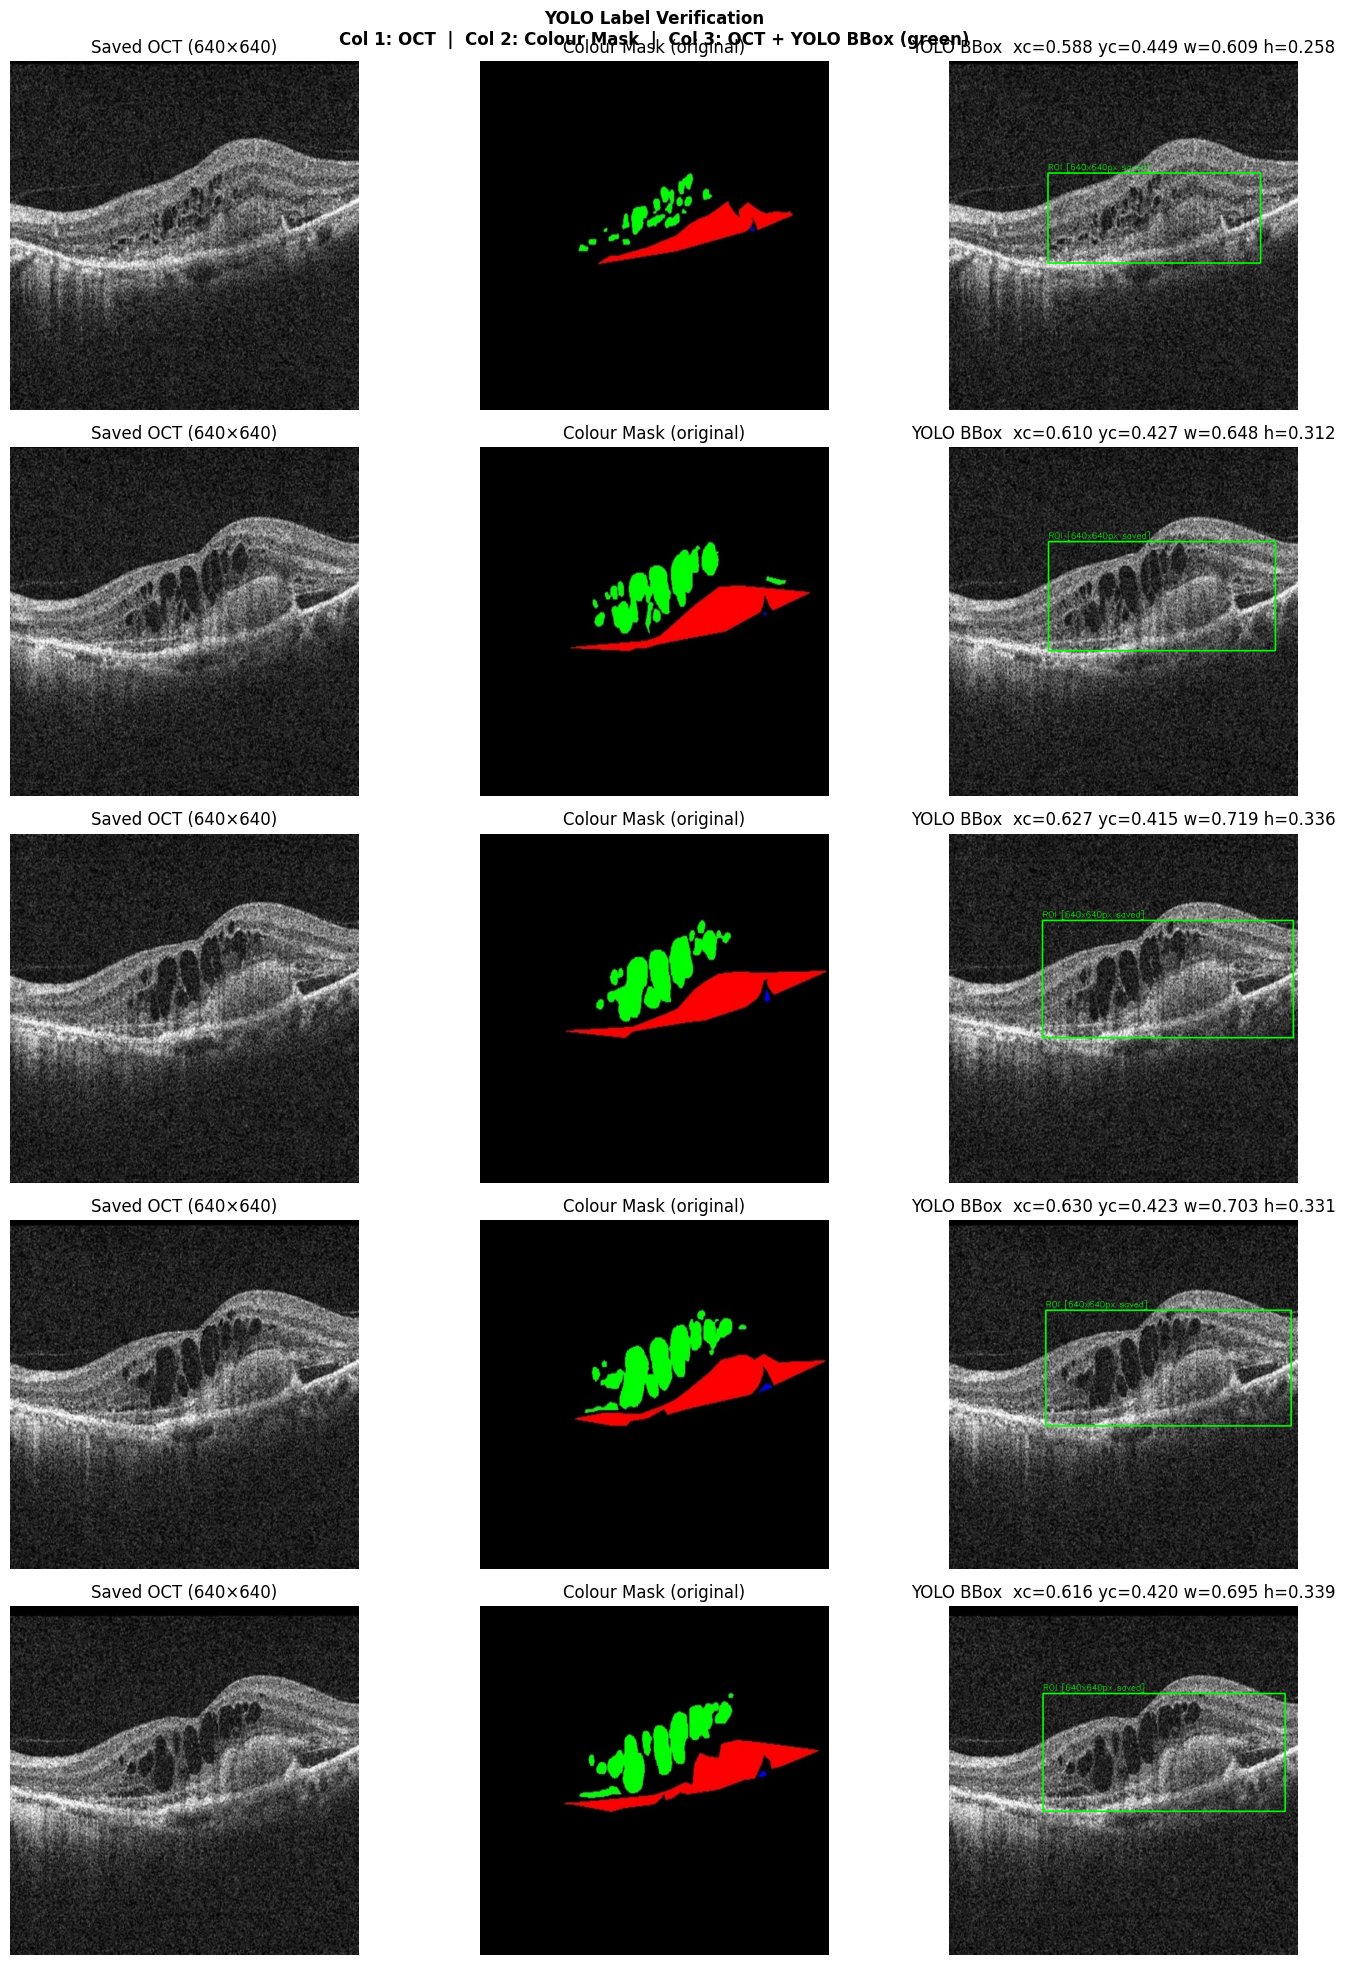

Saved → /content/yolo_verify.png


In [ ]:
# Verify YOLO bounding-box labels ─────────────────────────────────
#
# Each row: OCT image | original colour mask | OCT image + YOLO bbox
# The green box should tightly cover all coloured structures in the mask.

lbl_files = [f for f in sorted(glob.glob(f'{YOLO_LABELS}/*.txt'))
             if os.path.getsize(f) > 0]
n_show    = min(5, len(lbl_files))

print(f"Showing {n_show} / {len(lbl_files)} labelled images")

fig, axes = plt.subplots(n_show, 3, figsize=(15, 4*n_show))
if n_show == 1: axes = axes[np.newaxis,:]
fig.suptitle('YOLO Label Verification\n'
             'Col 1: OCT  |  Col 2: Colour Mask  |  Col 3: OCT + YOLO BBox (green)',
             fontsize=12, fontweight='bold')

for i, lbl_path in enumerate(lbl_files[:n_show]):
    stem     = os.path.splitext(os.path.basename(lbl_path))[0]
    img_path = os.path.join(YOLO_IMAGES, stem+'.png')
    img_bgr  = cv2.imread(img_path)
    img_rgb  = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2RGB)
    h, w     = img_bgr.shape[:2]

    # Decode label
    with open(lbl_path) as f: line = f.read().strip()
    _, xc, yc, bw, bh = map(float, line.split())
    x1 = int((xc - bw/2)*w);  y1 = int((yc - bh/2)*h)
    x2 = int((xc + bw/2)*w);  y2 = int((yc + bh/2)*h)

    # Get original colour mask for comparison
    raw_matches = glob.glob(f'{RAW_DIR}/**/{stem}.*', recursive=True) +                   glob.glob(f'{RAW_DIR}/{stem}.*')
    col_disp = np.zeros_like(img_rgb)
    if raw_matches:
        raw_bgr = cv2.imread(raw_matches[0])
        rw = raw_bgr.shape[1]
        right_half = cv2.cvtColor(raw_bgr[:, rw//2:], cv2.COLOR_BGR2RGB)
        col_disp = cv2.resize(right_half, (w, h))

    # Draw bbox on OCT
    img_box = img_rgb.copy()
    cv2.rectangle(img_box, (x1,y1),(x2,y2), (0,255,0), 2)
    cv2.putText(img_box, f'ROI [{w}x{h}px saved]',
                (x1, max(y1-6,14)), cv2.FONT_HERSHEY_SIMPLEX,
                0.5, (0,255,0), 1)

    axes[i,0].imshow(img_rgb);   axes[i,0].set_title(f'Saved OCT ({w}×{h})')
    axes[i,1].imshow(col_disp);  axes[i,1].set_title('Colour Mask (original)')
    axes[i,2].imshow(img_box);   axes[i,2].set_title(
        f'YOLO BBox  xc={xc:.3f} yc={yc:.3f} w={bw:.3f} h={bh:.3f}')
    axes[i,0].set_ylabel(stem, fontsize=7)
    for ax in axes[i]: ax.axis('off')

plt.tight_layout()
plt.savefig('/content/yolo_verify.png', dpi=120)
plt.show()
print("Saved → /content/yolo_verify.png")


In [ ]:
# Generate U-Net class-ID masks ───────────────────────────────────
#
# KEY POINT — U-Net can have a DIFFERENT input size from YOLO:
#   UNET_SIZE : (width, height) the U-Net is trained on
#
# The mask is resized with INTER_NEAREST (never INTER_LINEAR) to preserve
# class-ID integer values exactly — linear interpolation would create
# mixed values like 2.5 which are meaningless class IDs.
#
# Output mask pixel values: 0=Background 1=SRF 2=IRF 3=PED 4=IS/OS 5=SHRM

UNET_SIZE = (256, 256)    # (width, height) for U-Net — must match training config
                           # Set None to keep original OCT crop size

unet_saved, unet_skip = 0, 0

for raw_path in sorted(all_raw):
    img = cv2.imread(raw_path)
    if img is None:
        unet_skip += 1; continue

    h_full, w_full = img.shape[:2]
    oct_bgr  = img[:, :w_full//2]
    mask_bgr = img[:, w_full//2:]

    orig_h, orig_w = oct_bgr.shape[:2]

    # ── Resize OCT for U-Net ──────────────────────────────────────────────
    if UNET_SIZE is not None:
        uw, uh    = UNET_SIZE
        unet_oct  = cv2.resize(oct_bgr, (uw, uh), interpolation=cv2.INTER_LINEAR)
    else:
        unet_oct  = oct_bgr.copy()
        uw, uh    = orig_w, orig_h

    # ── Convert colour mask → class-ID mask ──────────────────────────────
    class_mask = rgb_mask_to_class(mask_bgr)   # still in original mask size

    # ── Resize class-ID mask to U-Net size ───────────────────────────────
    # MUST use INTER_NEAREST — preserves integer class IDs exactly
    if UNET_SIZE is not None:
        class_mask = cv2.resize(class_mask, (uw, uh),
                                interpolation=cv2.INTER_NEAREST)

    # ── Save OCT as grayscale ─────────────────────────────────────────────
    oct_gray = cv2.cvtColor(unet_oct, cv2.COLOR_BGR2GRAY)                if unet_oct.ndim == 3 else unet_oct
    stem      = os.path.splitext(os.path.basename(raw_path))[0]
    out_fname = stem + '.png'

    cv2.imwrite(os.path.join(UNET_IMAGES, out_fname), oct_gray)

    # class_mask pixel values are 0-5 → saved as single-channel PNG
    cv2.imwrite(os.path.join(UNET_MASKS, out_fname), class_mask)

    # ── Save verification overlay ─────────────────────────────────────────
    vis      = class_mask_to_rgb(class_mask)
    oct_rgb  = cv2.cvtColor(oct_gray, cv2.COLOR_GRAY2RGB)
    overlay  = cv2.addWeighted(oct_rgb, 0.55, vis, 0.45, 0)
    cv2.imwrite(os.path.join(UNET_VISUAL, out_fname),
                cv2.cvtColor(overlay, cv2.COLOR_RGB2BGR))

    unet_saved += 1

print("── U-Net Annotation Summary ──────────────────────────────────────────")
print(f"  ✅ Pairs saved     : {unet_saved}")
print(f"  ✗  Skipped        : {unet_skip}")
print(f"\n  U-Net image size  : {UNET_SIZE if UNET_SIZE else 'original'}")
print(f"  Mask resize method: INTER_NEAREST (preserves class IDs)")
print(f"  Mask pixel values : 0–{NUM_CLASSES-1} (class IDs)")
print(f"\n  Images → {UNET_IMAGES}")
print(f"  Masks  → {UNET_MASKS}")


── U-Net Annotation Summary ──────────────────────────────────────────
  ✅ Pairs saved     : 3049
  ✗  Skipped        : 0

  U-Net image size  : (256, 256)
  Mask resize method: INTER_NEAREST (preserves class IDs)
  Mask pixel values : 0–5 (class IDs)

  Images → /content/drive/MyDrive/FYP/unet_data/images
  Masks  → /content/drive/MyDrive/FYP/unet_data/masks


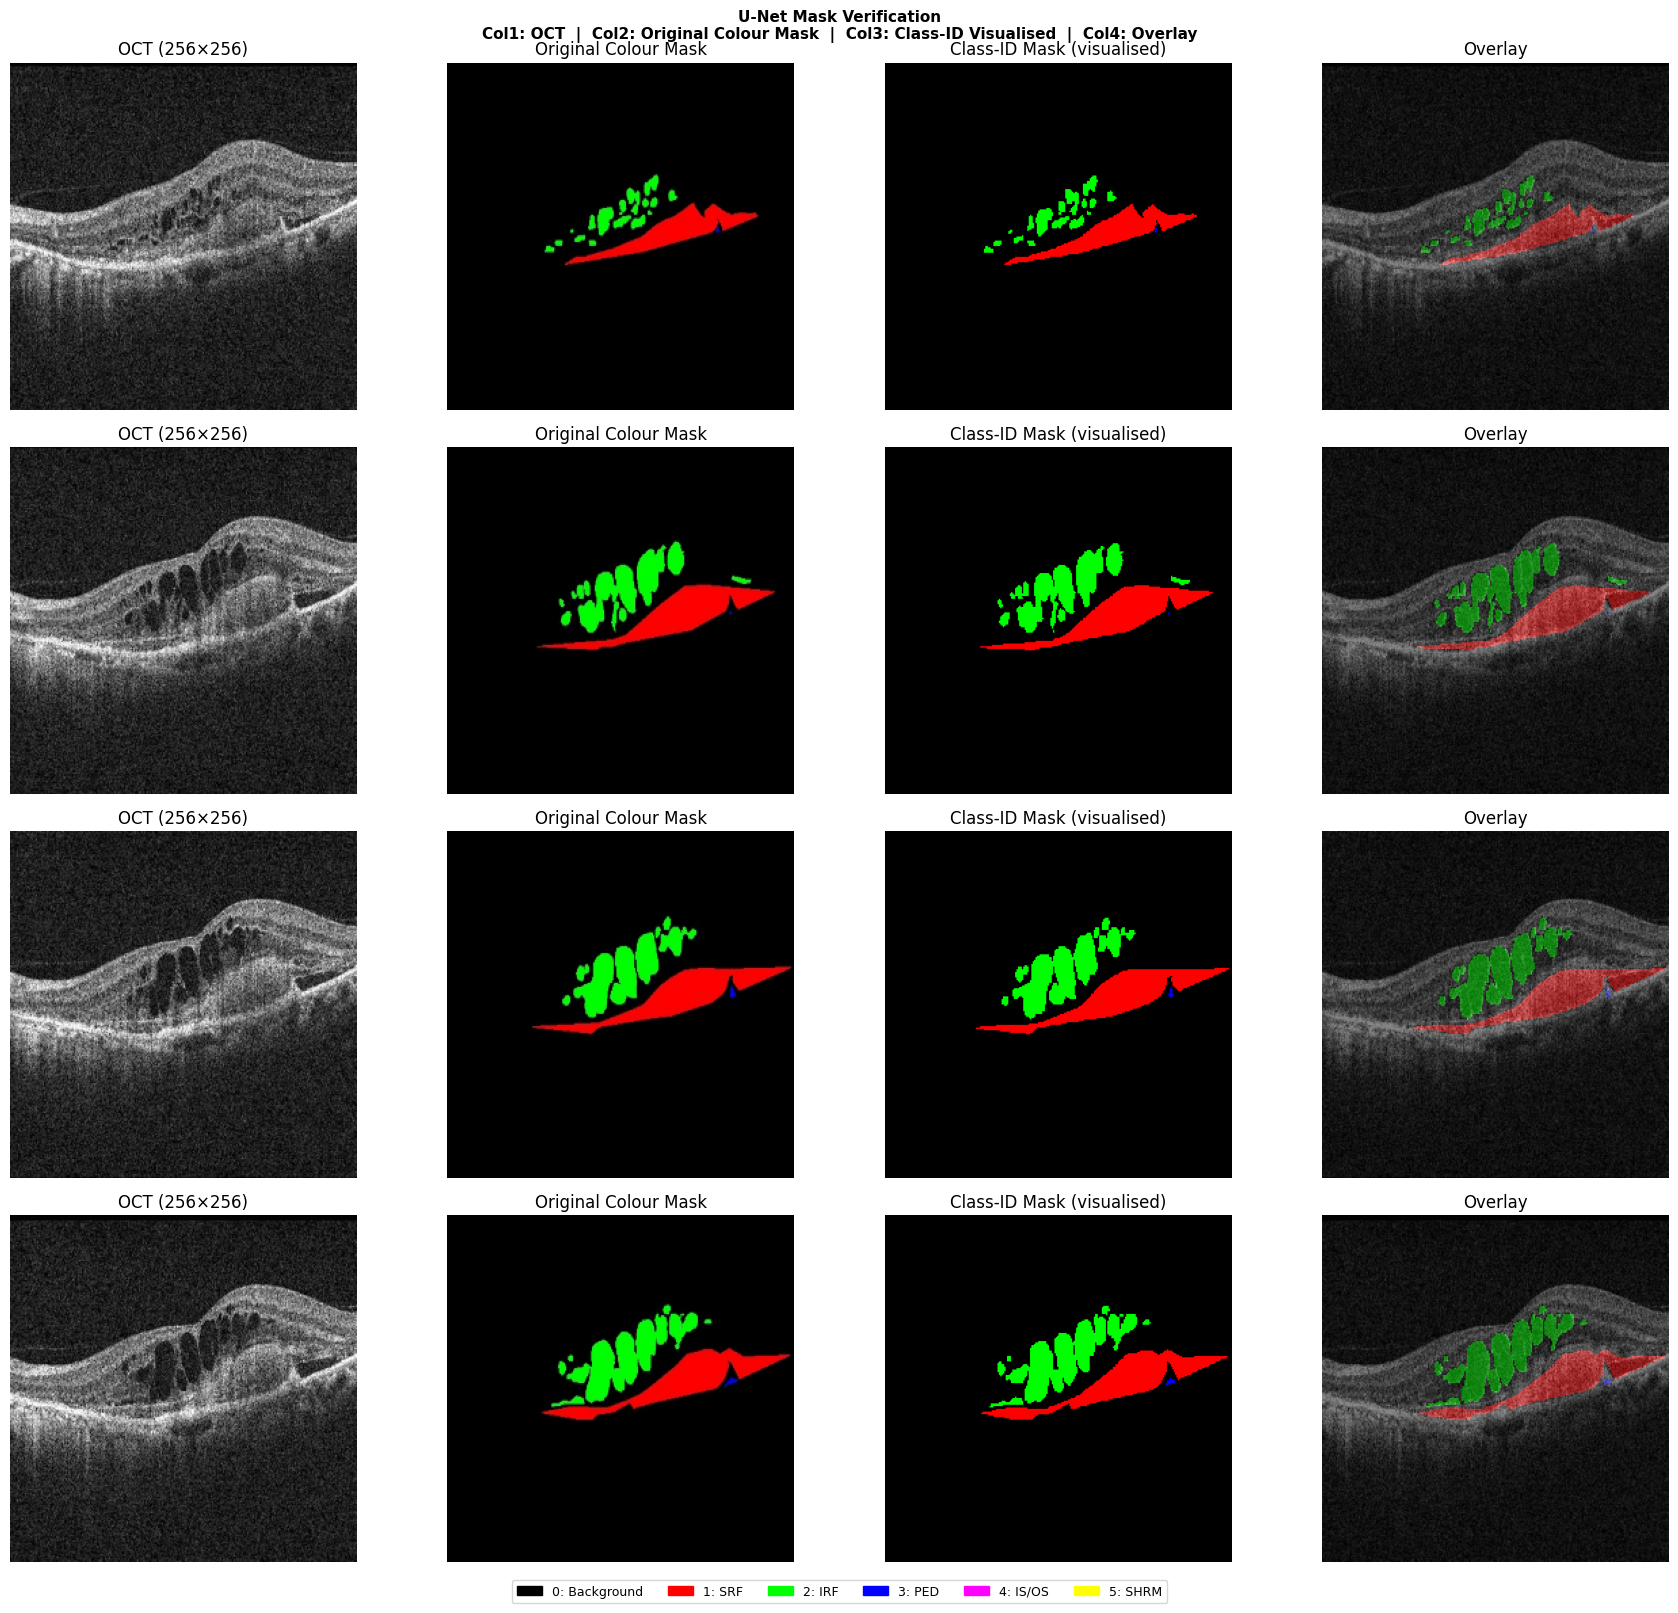

Saved → /content/unet_mask_verify.png

── Pixel Value Sanity Check ──────────────────────────────────────────
  (All pixels must be integers 0–5 only)
  ✅  100_100_1.png                       values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_10.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_11.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_12.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_13.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_14.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2)]
  ✅  100_100_15.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3), np.uint8(5)]
  ✅  100_100_16.png                      values=[np.uint8(0), np.uint8(1), np.uint8(2), np.uint8(3)]
  ✅  100_100_17.png                      

In [ ]:
# Verify U-Net masks ──────────────────────────────────────────────

mask_files = sorted(glob.glob(f'{UNET_MASKS}/*.png'))
n_show     = min(4, len(mask_files))

fig, axes = plt.subplots(n_show, 4, figsize=(18, 4*n_show))
if n_show == 1: axes = axes[np.newaxis,:]
fig.suptitle(
    'U-Net Mask Verification\n'
    'Col1: OCT  |  Col2: Original Colour Mask  |  Col3: Class-ID Visualised  |  Col4: Overlay',
    fontsize=11, fontweight='bold')

for i, mp in enumerate(mask_files[:n_show]):
    stem      = os.path.splitext(os.path.basename(mp))[0]
    oct_img   = cv2.imread(os.path.join(UNET_IMAGES, stem+'.png'), cv2.IMREAD_GRAYSCALE)
    cls_mask  = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    vis_rgb   = class_mask_to_rgb(cls_mask)
    oct_rgb   = cv2.cvtColor(oct_img, cv2.COLOR_GRAY2RGB)
    overlay   = cv2.addWeighted(oct_rgb, 0.55, vis_rgb, 0.45, 0)

    raw_matches = glob.glob(f'{RAW_DIR}/**/{stem}.*', recursive=True) +                   glob.glob(f'{RAW_DIR}/{stem}.*')
    col_orig = np.zeros_like(oct_rgb)
    if raw_matches:
        raw_bgr  = cv2.imread(raw_matches[0])
        rw       = raw_bgr.shape[1]
        col_orig = cv2.resize(
            cv2.cvtColor(raw_bgr[:, rw//2:], cv2.COLOR_BGR2RGB),
            (oct_img.shape[1], oct_img.shape[0]))

    axes[i,0].imshow(oct_img,  cmap='gray')
    axes[i,0].set_title(f'OCT ({oct_img.shape[1]}×{oct_img.shape[0]})')
    axes[i,1].imshow(col_orig)
    axes[i,1].set_title('Original Colour Mask')
    axes[i,2].imshow(vis_rgb)
    axes[i,2].set_title('Class-ID Mask (visualised)')
    axes[i,3].imshow(overlay)
    axes[i,3].set_title('Overlay')
    axes[i,0].set_ylabel(stem, fontsize=7)

    present = np.unique(cls_mask)
    present_names = [f"{c}:{CLASS_INFO[c]['name']}" for c in present]
    axes[i,2].set_xlabel(f"Classes: {', '.join(present_names)}", fontsize=7)
    for ax in axes[i]: ax.axis('off')

legend_handles = [
    mpatches.Patch(color=[c/255 for c in info['rgb']], label=f"{cid}: {info['name']}")
    for cid, info in CLASS_INFO.items()
]
fig.legend(handles=legend_handles, loc='lower center', ncol=6,
           fontsize=9, bbox_to_anchor=(0.5,-0.02))
plt.tight_layout()
plt.savefig('/content/unet_mask_verify.png', dpi=120, bbox_inches='tight')
plt.show()
print("Saved → /content/unet_mask_verify.png")

# ── Critical pixel-value check ────────────────────────────────────────────
print("\n── Pixel Value Sanity Check ──────────────────────────────────────────")
print("  (All pixels must be integers 0–5 only)")
all_ok = True
for mp in sorted(glob.glob(f'{UNET_MASKS}/*.png'))[:15]:
    cls = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    uniq = np.unique(cls)
    bad  = [v for v in uniq if v >= NUM_CLASSES]
    status = '✅' if not bad else '❌'
    print(f"  {status}  {os.path.basename(mp):<35} values={list(uniq)}", end='')
    if bad:
        print(f"  ⚠️ UNEXPECTED: {bad}")
        all_ok = False
    else:
        print()

print()
if all_ok:
    print("✅ All masks correct — pixel values are in range 0–5")
else:
    print("❌ Fix: adjust CLASS_INFO RGB values in Cell 4 and re-run Cells 7 & 8")


In [ ]:
# Image size summary & size mismatch check ────────────────────────
#
# This cell confirms that YOLO images, U-Net images, and their labels/masks
# all have consistent sizes. It also shows what scale factors were applied
# from the original OCT crop to each model's input.

orig_sample = cv2.imread(all_raw[0])
orig_h, orig_w_full = orig_sample.shape[:2]
orig_w_oct = orig_w_full // 2   # OCT is the left half

yolo_sample = cv2.imread(sorted(glob.glob(f'{YOLO_IMAGES}/*.png'))[0])
unet_sample = cv2.imread(sorted(glob.glob(f'{UNET_IMAGES}/*.png'))[0], cv2.IMREAD_GRAYSCALE)
mask_sample = cv2.imread(sorted(glob.glob(f'{UNET_MASKS}/*.png'))[0],  cv2.IMREAD_GRAYSCALE)

print("── Image Size Summary ────────────────────────────────────────────────")
print(f"  Original OCT crop     : {orig_w_oct} × {orig_h} px")
print(f"  YOLO saved image      : {yolo_sample.shape[1]} × {yolo_sample.shape[0]} px")
print(f"  U-Net saved image     : {unet_sample.shape[1]} × {unet_sample.shape[0]} px")
print(f"  U-Net mask            : {mask_sample.shape[1]} × {mask_sample.shape[0]} px")
print()

scale_x_yolo = yolo_sample.shape[1] / orig_w_oct
scale_y_yolo = yolo_sample.shape[0] / orig_h
scale_x_unet = unet_sample.shape[1] / orig_w_oct
scale_y_unet = unet_sample.shape[0] / orig_h

print(f"  Scale applied to YOLO : x={scale_x_yolo:.3f}, y={scale_y_yolo:.3f}")
print(f"  Scale applied to UNet : x={scale_x_unet:.3f}, y={scale_y_unet:.3f}")

# Size consistency check
print()
if unet_sample.shape == mask_sample.shape:
    print("  ✅ U-Net image and mask sizes match")
else:
    print(f"  ❌ SIZE MISMATCH: image={unet_sample.shape} mask={mask_sample.shape}")

print()
print("── Paths for Training Notebooks ─────────────────────────────────────")
print(f"  YOLOv8  data.yaml     : {YOLO_SPLIT}/data.yaml  (created in Cell 10)")
print(f"  U-Net   image_dir     : {UNET_SPLIT}/images/train")
print(f"  U-Net   mask_dir      : {UNET_SPLIT}/masks/train")
print(f"  U-Net   image_size    : {unet_sample.shape[1]}   (use this in CONFIG)")


── Image Size Summary ────────────────────────────────────────────────
  Original OCT crop     : 570 × 380 px
  YOLO saved image      : 640 × 640 px
  U-Net saved image     : 256 × 256 px
  U-Net mask            : 256 × 256 px

  Scale applied to YOLO : x=1.123, y=1.684
  Scale applied to UNet : x=0.449, y=0.674

  ✅ U-Net image and mask sizes match

── Paths for Training Notebooks ─────────────────────────────────────
  YOLOv8  data.yaml     : /content/drive/MyDrive/FYP/yolo_dataset/data.yaml  (created in Cell 10)
  U-Net   image_dir     : /content/drive/MyDrive/FYP/unet_dataset/images/train
  U-Net   mask_dir      : /content/drive/MyDrive/FYP/unet_dataset/masks/train
  U-Net   image_size    : 256   (use this in CONFIG)


Computing class pixel distribution (may take a moment)...

── Class Distribution (3049 masks, 199,819,264 total pixels) ──────────────────
  ID   Class                Pixels        %  Bar
  -------------------------------------------------------
  0    Background      192,761,360   96.47%  ████████████████████████████████████████████████
  1    SRF               1,734,358    0.87%  
  2    IRF                 361,466    0.18%  
  3    PED               2,008,715    1.01%  
  4    IS/OS             1,097,125    0.55%  
  5    SHRM              1,856,240    0.93%  

── Suggested Class Weights (copy into training notebook) ────────────
  CLASS_WEIGHTS = [np.float64(0.0625), np.float64(0.6472), np.float64(3.1038), np.float64(0.5588), np.float64(1.023), np.float64(0.6047)]


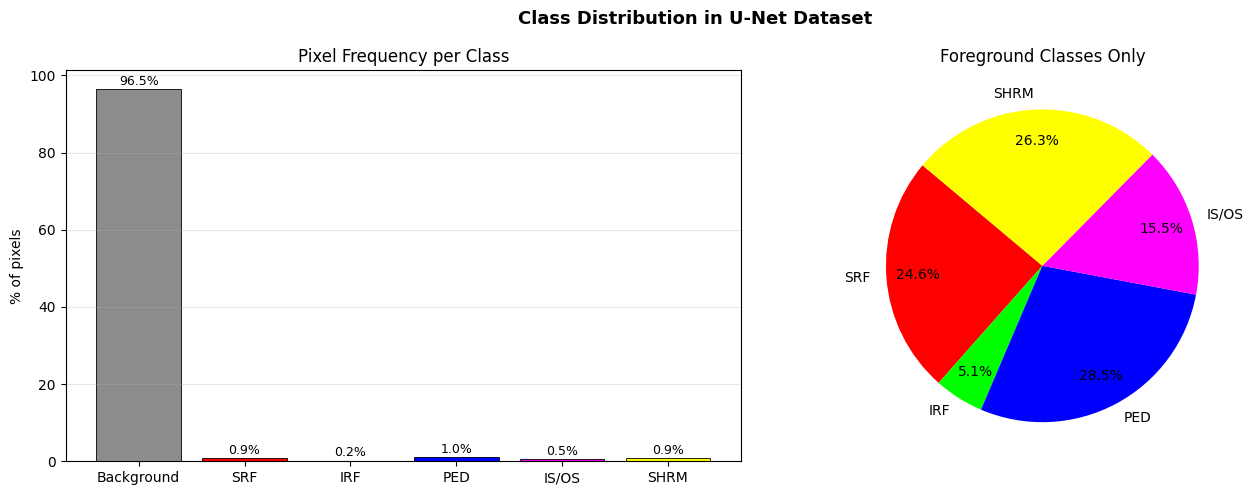

Saved → /content/class_distribution.png


In [ ]:
# Class distribution + suggested class weights ───────────────────

print("Computing class pixel distribution (may take a moment)...")

counts = np.zeros(NUM_CLASSES, dtype=np.int64)
n_imgs = 0
for mp in sorted(glob.glob(f'{UNET_MASKS}/*.png')):
    cls = cv2.imread(mp, cv2.IMREAD_GRAYSCALE)
    for c in range(NUM_CLASSES):
        counts[c] += int(np.sum(cls == c))
    n_imgs += 1

total = counts.sum()
freqs = counts / total

print(f"\n── Class Distribution ({n_imgs} masks, {total:,} total pixels) ──────────────────")
print(f"  {'ID':<4} {'Class':<14} {'Pixels':>12}  {'%':>7}  Bar")
print("  " + "-"*55)
for cid, info in CLASS_INFO.items():
    pct = 100 * freqs[cid]
    bar = '█' * int(pct / 2)
    print(f"  {cid:<4} {info['name']:<14} {counts[cid]:>12,}  {pct:>6.2f}%  {bar}")

# Suggested class weights (median-frequency balancing)
median_f = np.median(freqs)
weights  = np.clip(median_f / (freqs + 1e-6), 0.1, 10.0)
weights  = weights / weights.sum() * NUM_CLASSES

print(f"\n── Suggested Class Weights (copy into training notebook) ────────────")
print(f"  CLASS_WEIGHTS = {list(np.round(weights,4))}")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14,5))
fig.suptitle('Class Distribution in U-Net Dataset', fontsize=13, fontweight='bold')

colors = [[c/255 for c in info['rgb']] for info in CLASS_INFO.values()]
colors[0] = [0.55,0.55,0.55]   # grey for background (black is invisible)
names  = [info['name'] for info in CLASS_INFO.values()]

bars = axes[0].bar(names, freqs*100, color=colors, edgecolor='black', lw=0.6)
axes[0].set_ylabel('% of pixels'); axes[0].set_title('Pixel Frequency per Class')
axes[0].grid(axis='y', alpha=0.3)
for bar, pct in zip(bars, freqs*100):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.3,
                 f'{pct:.1f}%', ha='center', va='bottom', fontsize=9)

fg = counts[1:]; fg_names = names[1:]; fg_colors = colors[1:]
if fg.sum()>0:
    axes[1].pie(fg, labels=fg_names, colors=fg_colors,
                autopct='%1.1f%%', startangle=140, pctdistance=0.8)
axes[1].set_title('Foreground Classes Only')

plt.tight_layout()
plt.savefig('/content/class_distribution.png', dpi=120)
plt.show()
print("Saved → /content/class_distribution.png")


In [ ]:
# Train / Val / Test split & final folder structure ──────────────

SPLIT_RATIOS = {'train':0.70, 'val':0.15, 'test':0.15}
RANDOM_SEED  = 42

# Only use images that have a real (non-empty) YOLO label
labelled = [
    os.path.splitext(os.path.basename(f))[0]
    for f in sorted(glob.glob(f'{YOLO_LABELS}/*.txt'))
    if os.path.getsize(f) > 0
]

random.seed(RANDOM_SEED)
random.shuffle(labelled)
n      = len(labelled)
n_tr   = int(SPLIT_RATIOS['train']*n)
n_va   = int(SPLIT_RATIOS['val']*n)
splits = {
    'train': labelled[:n_tr],
    'val'  : labelled[n_tr:n_tr+n_va],
    'test' : labelled[n_tr+n_va:],
}

# ── Build YOLO split ──────────────────────────────────────────────────────
for sp in ['train','val','test']:
    os.makedirs(f'{YOLO_SPLIT}/images/{sp}', exist_ok=True)
    os.makedirs(f'{YOLO_SPLIT}/labels/{sp}', exist_ok=True)

for sp, stems in splits.items():
    for stem in stems:
        for src_dir, dst_dir, ext in [
            (YOLO_IMAGES, f'{YOLO_SPLIT}/images/{sp}', '.png'),
            (YOLO_LABELS, f'{YOLO_SPLIT}/labels/{sp}', '.txt'),
        ]:
            src = os.path.join(src_dir, stem+ext)
            if os.path.exists(src):
                shutil.copy(src, dst_dir)

data_yaml = {
    'path' : YOLO_SPLIT,
    'train': 'images/train',
    'val'  : 'images/val',
    'test' : 'images/test',
    'nc'   : 1,
    'names': ['roi'],
}
yaml_path = f'{YOLO_SPLIT}/data.yaml'
with open(yaml_path, 'w') as f:
    yaml.dump(data_yaml, f, default_flow_style=False)

# ── Build U-Net split ─────────────────────────────────────────────────────
for sp in ['train','val','test']:
    os.makedirs(f'{UNET_SPLIT}/images/{sp}', exist_ok=True)
    os.makedirs(f'{UNET_SPLIT}/masks/{sp}',  exist_ok=True)

for sp, stems in splits.items():
    for stem in stems:
        for src_dir, dst_dir in [
            (UNET_IMAGES, f'{UNET_SPLIT}/images/{sp}'),
            (UNET_MASKS,  f'{UNET_SPLIT}/masks/{sp}'),
        ]:
            src = os.path.join(src_dir, stem+'.png')
            if os.path.exists(src):
                shutil.copy(src, dst_dir)

# ── Print summary ─────────────────────────────────────────────────────────
print("── Final Dataset Summary ─────────────────────────────────────────────")
print(f"  Total labelled images : {n}")
print()
print("  YOLO Dataset:")
for sp in ['train','val','test']:
    ni = len(glob.glob(f'{YOLO_SPLIT}/images/{sp}/*.png'))
    nl = len(glob.glob(f'{YOLO_SPLIT}/labels/{sp}/*.txt'))
    print(f"    {sp:<6}: {ni:4d} images  {nl:4d} labels")
print(f"    data.yaml → {yaml_path}")
print()
print("  U-Net Dataset:")
for sp in ['train','val','test']:
    ni = len(glob.glob(f'{UNET_SPLIT}/images/{sp}/*.png'))
    nm = len(glob.glob(f'{UNET_SPLIT}/masks/{sp}/*.png'))
    ok = '✅' if ni==nm else '❌ MISMATCH'
    print(f"    {sp:<6}: {ni:4d} images  {nm:4d} masks  {ok}")
print()
print("── Copy these paths into your training notebook ──────────────────────")
print(f"  YOLO_DATA_YAML  = '{yaml_path}'")
print(f"  UNET_IMAGE_DIR  = '{UNET_SPLIT}/images'")
print(f"  UNET_MASK_DIR   = '{UNET_SPLIT}/masks'")
print()
print("✅ Annotation pipeline complete — both datasets are ready for training!")


── Final Dataset Summary ─────────────────────────────────────────────
  Total labelled images : 3042

  YOLO Dataset:
    train : 2129 images  2129 labels
    val   :  456 images   456 labels
    test  :  457 images   457 labels
    data.yaml → /content/drive/MyDrive/FYP/yolo_dataset/data.yaml

  U-Net Dataset:
    train : 2129 images  2129 masks  ✅
    val   :  456 images   456 masks  ✅
    test  :  457 images   457 masks  ✅

── Copy these paths into your training notebook ──────────────────────
  YOLO_DATA_YAML  = '/content/drive/MyDrive/FYP/yolo_dataset/data.yaml'
  UNET_IMAGE_DIR  = '/content/drive/MyDrive/FYP/unet_dataset/images'
  UNET_MASK_DIR   = '/content/drive/MyDrive/FYP/unet_dataset/masks'

✅ Annotation pipeline complete — both datasets are ready for training!
